# PHASE 12.2 — CLEAN CHAMPION VS CANDIDATE HEAD-TO-HEAD EVALUATION

**Project:** Student Mental Health / Wellbeing Score Prediction  
**Phase:** 12.2 — Clean Champion vs Candidate Head-to-Head Evaluation  
**Production Champion Model:** `models/phase5_tuned_extra_trees.joblib` (SHA-256: `a012e7a1c0ca5c9fccb21d1e46bf3b4b4a72635204c13efdc4f93d6c636747f8`)  
**Candidate Challenger Model:** `models/candidate_v1_2_revalidated.joblib` (SHA-256: `aad2f208a298289de57a0a8fd4aef941be0edaf940439dca98eaaf718439cdbc`)  
**Evaluation Standard:** Strictly Symmetric, Leakage-Free Head-to-Head Evaluation on the Clean Common Evaluation Subset ($N=201$)  
**Notebook Artifact:** `ml/notebooks/12_2_clean_champion_candidate_evaluation.ipynb`  

---

## 1. Executive Summary & Purpose

In Phase 12.1, a rigorous audit established that the 1,000-row Phase 12 evaluation holdout was **contaminated for evaluating the Champion** because 799 rows (79.90%) belonged to the Phase 5 training pool.

Phase 12.2 performs a **strictly symmetric, leakage-free head-to-head comparison** between the frozen Champion and Candidate v1.2 using exclusively the **201 records that are provably unseen by BOTH models**:
$$\text{Clean Common Evaluation Subset} = \text{Phase 5 Holdout} \cap \text{Phase 12 Holdout} \quad (N=201)$$

### Core Verification Rules:
1. Both models receive the exact same 201 records.
2. Zero training overlap for the Champion ($0$ rows).
3. Zero training overlap for the Candidate ($0$ rows).
4. Frozen model pipelines and calibrations are loaded directly from disk without modification.


## 2. Artifact Integrity Verification

Cryptographically verify both model joblib artifacts and both calibration JSON files before evaluation.


In [1]:
import os
import sys
import json
import hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy import stats
from sklearn.model_selection import train_test_split

ROOT_DIR = Path.cwd().parent.parent if "notebooks" in str(Path.cwd()) else Path.cwd()
sys.path.insert(0, str(ROOT_DIR))

from app.monitoring import TOP10_COUNTRIES

champ_path = ROOT_DIR / "models" / "phase5_tuned_extra_trees.joblib"
cand_path = ROOT_DIR / "models" / "candidate_v1_2_revalidated.joblib"
champ_calib_path = ROOT_DIR / "models" / "phase7_1_conformal_calibration.json"
cand_calib_path = ROOT_DIR / "models" / "candidate_v1_2_conformal_calibration.json"

with open(champ_path, "rb") as f:
    champ_hash = hashlib.sha256(f.read()).hexdigest()
with open(cand_path, "rb") as f:
    cand_hash = hashlib.sha256(f.read()).hexdigest()

champ_expected_hash = "a012e7a1c0ca5c9fccb21d1e46bf3b4b4a72635204c13efdc4f93d6c636747f8"
cand_expected_hash = "aad2f208a298289de57a0a8fd4aef941be0edaf940439dca98eaaf718439cdbc"

assert champ_hash.lower() == champ_expected_hash.lower(), "Champion SHA-256 mismatch!"
assert cand_hash.lower() == cand_expected_hash.lower(), "Candidate SHA-256 mismatch!"

with open(champ_calib_path, "r", encoding="utf-8") as f:
    champ_calib = json.load(f)
with open(cand_calib_path, "r", encoding="utf-8") as f:
    cand_calib = json.load(f)

assert champ_calib["source_model_hash"].lower() == champ_expected_hash.lower()
assert cand_calib["source_model_hash"].lower() == cand_expected_hash.lower()

print("ARTIFACT INTEGRITY VERIFICATION: PASSED")
print(f"  Champion SHA-256:  {champ_hash}")
print(f"  Candidate SHA-256: {cand_hash}")


ARTIFACT INTEGRITY VERIFICATION: PASSED
  Champion SHA-256:  a012e7a1c0ca5c9fccb21d1e46bf3b4b4a72635204c13efdc4f93d6c636747f8
  Candidate SHA-256: aad2f208a298289de57a0a8fd4aef941be0edaf940439dca98eaaf718439cdbc


## 3. Historical Split Reconstruction & Extraction of the Clean 201-Row Subset

Reconstruct all four historical partitions deterministically:
- `p5_train`, `p5_holdout` via `random_state=42`
- `p12_dev`, `p12_holdout` via `random_state=1242`
Extract `clean_common_df = p5_holdout ∩ p12_holdout` and verify zero training overlap.


In [2]:
data_path = ROOT_DIR / "ml" / "data" / "Student Social Media And Mental Health Impact.csv"
raw_df = pd.read_csv(data_path).drop_duplicates()
raw_df["Grouped_country"] = raw_df["Country"].apply(lambda c: c if c in TOP10_COUNTRIES else "Other")

feature_cols = [
    "Study_Hours", "Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks",
    "Physical_Activity_Hours", "Sleep_Hours_Per_Night", "Stress_Level",
    "Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use",
    "Grouped_country"
]
target_col = "Mental_Health_Score"

p5_train, p5_holdout = train_test_split(raw_df, test_size=1000, random_state=42)
p12_dev, p12_holdout = train_test_split(raw_df, test_size=1000, random_state=1242)

def compute_fingerprint(row):
    row_str = "|".join([f"{k}:{v}" for k, v in sorted(row.items())])
    return hashlib.sha256(row_str.encode("utf-8")).hexdigest()

p5_holdout_fps = set(p5_holdout.apply(compute_fingerprint, axis=1))
p12_holdout_fps = set(p12_holdout.apply(compute_fingerprint, axis=1))
p5_train_fps = set(p5_train.apply(compute_fingerprint, axis=1))
p12_dev_fps = set(p12_dev.apply(compute_fingerprint, axis=1))

clean_fps = p5_holdout_fps.intersection(p12_holdout_fps)
assert len(clean_fps) == 201, f"Expected 201 rows, got {len(clean_fps)}"
assert len(clean_fps.intersection(p5_train_fps)) == 0, "Champion training leakage detected!"
assert len(clean_fps.intersection(p12_dev_fps)) == 0, "Candidate training leakage detected!"

clean_idx = p5_holdout.index.intersection(p12_holdout.index)
clean_df = raw_df.loc[clean_idx].copy()
clean_df["row_fingerprint"] = clean_df.apply(compute_fingerprint, axis=1)

print("CLEAN COMMON EVALUATION SUBSET VERIFIED:")
print(f"  Total records:                    {len(clean_df)}")
print(f"  Unique cryptographic fingerprints:{clean_df['row_fingerprint'].nunique()}")
print(f"  Champion training overlap:        0 rows (0.0%)")
print(f"  Candidate training overlap:       0 rows (0.0%)")


CLEAN COMMON EVALUATION SUBSET VERIFIED:
  Total records:                    201
  Unique cryptographic fingerprints:201
  Champion training overlap:        0 rows (0.0%)
  Candidate training overlap:       0 rows (0.0%)


## 4. Model Inference & Raw Prediction Divergence Audit

Generate point predictions for both models on the exact same 201 records.
Confirm that predictions are distinct and generated independently.


In [3]:
champ = joblib.load(champ_path)
cand = joblib.load(cand_path)

X_clean = clean_df[feature_cols]
y_true = clean_df[target_col].values

champ_preds = champ.predict(X_clean)
cand_preds = cand.predict(X_clean)

pred_diff = cand_preds - champ_preds
abs_diff = np.abs(pred_diff)

max_abs_diff = float(np.max(abs_diff))
mean_abs_diff = float(np.mean(abs_diff))
rmse_diff = float(np.sqrt(np.mean(pred_diff**2)))
exact_equals = int(np.sum(abs_diff == 0))

print("RAW PREDICTION DIVERGENCE AUDIT (N=201):")
print(f"  Max Absolute Difference:     {max_abs_diff:.6f}")
print(f"  Mean Absolute Difference:    {mean_abs_diff:.6f}")
print(f"  RMSE Between Predictions:    {rmse_diff:.6f}")
print(f"  Exact Equal Predictions:     {exact_equals} / 201")
assert exact_equals == 0, "Models unexpectedly generated identical predictions!"
print("STATUS: INDEPENDENT INFERENCE CONFIRMED.")


RAW PREDICTION DIVERGENCE AUDIT (N=201):
  Max Absolute Difference:     1.246200
  Mean Absolute Difference:    0.097982
  RMSE Between Predictions:    0.188498
  Exact Equal Predictions:     0 / 201
STATUS: INDEPENDENT INFERENCE CONFIRMED.


## 5. Point Prediction Metrics Comparison (N=201)

Compute standard regression metrics on the clean common subset:
- $R^2$, RMSE, MAE, Mean Error (Bias), Median Absolute Error, Maximum Absolute Error.


In [4]:
def calc_metrics(y, y_hat):
    ss_tot = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - y_hat)**2)
    r2 = 1.0 - (ss_res / ss_tot)
    rmse = np.sqrt(np.mean((y - y_hat)**2))
    mae = np.mean(np.abs(y - y_hat))
    mean_err = np.mean(y_hat - y)
    med_ae = np.median(np.abs(y - y_hat))
    max_ae = np.max(np.abs(y - y_hat))
    return {
        "R2": r2, "RMSE": rmse, "MAE": mae,
        "Mean_Error": mean_err, "Median_AE": med_ae, "Max_AE": max_ae
    }

champ_m = calc_metrics(y_true, champ_preds)
cand_m = calc_metrics(y_true, cand_preds)

metrics_table = [
    {"Metric": "R²", "Champion": champ_m["R2"], "Candidate": cand_m["R2"], "Delta (Cand - Champ)": cand_m["R2"] - champ_m["R2"], "Preferred": "Candidate (Higher)"},
    {"Metric": "RMSE", "Champion": champ_m["RMSE"], "Candidate": cand_m["RMSE"], "Delta (Cand - Champ)": cand_m["RMSE"] - champ_m["RMSE"], "Preferred": "Candidate (Lower)"},
    {"Metric": "MAE", "Champion": champ_m["MAE"], "Candidate": cand_m["MAE"], "Delta (Cand - Champ)": cand_m["MAE"] - champ_m["MAE"], "Preferred": "Candidate (Lower)"},
    {"Metric": "Mean Error (Bias)", "Champion": champ_m["Mean_Error"], "Candidate": cand_m["Mean_Error"], "Delta (Cand - Champ)": cand_m["Mean_Error"] - champ_m["Mean_Error"], "Preferred": "Near Zero"},
    {"Metric": "Median AE", "Champion": champ_m["Median_AE"], "Candidate": cand_m["Median_AE"], "Delta (Cand - Champ)": cand_m["Median_AE"] - champ_m["Median_AE"], "Preferred": "Champion (Lower)"},
    {"Metric": "Max AE", "Champion": champ_m["Max_AE"], "Candidate": cand_m["Max_AE"], "Delta (Cand - Champ)": cand_m["Max_AE"] - champ_m["Max_AE"], "Preferred": "Candidate (Lower)"}
]

df_metrics = pd.DataFrame(metrics_table)
print("POINT PREDICTION METRICS (N=201):")
print(df_metrics.to_string(index=False))


POINT PREDICTION METRICS (N=201):
           Metric  Champion  Candidate  Delta (Cand - Champ)          Preferred
               R²  0.909767   0.939649              0.029882 Candidate (Higher)
             RMSE  0.407234   0.333045             -0.074190  Candidate (Lower)
              MAE  0.263506   0.250220             -0.013285  Candidate (Lower)
Mean Error (Bias) -0.002367   0.008550              0.010917          Near Zero
        Median AE  0.178400   0.188000              0.009600   Champion (Lower)
           Max AE  2.080200   1.380000             -0.700200  Candidate (Lower)


## 6. Paired Error Analysis

Because both models predict the exact same 201 records, we perform record-by-record paired error comparison.


In [5]:
champ_abs_err = np.abs(y_true - champ_preds)
cand_abs_err = np.abs(y_true - cand_preds)
abs_err_diff = cand_abs_err - champ_abs_err
sq_err_diff = (y_true - cand_preds)**2 - (y_true - champ_preds)**2

cand_wins = int(np.sum(cand_abs_err < champ_abs_err))
champ_wins = int(np.sum(cand_abs_err > champ_abs_err))
exact_ties = int(np.sum(cand_abs_err == champ_abs_err))

print("PAIRED ERROR COMPARISON:")
print(f"  Mean Absolute Error Difference:   {np.mean(abs_err_diff):.6f}")
print(f"  Median Absolute Error Difference: {np.median(abs_err_diff):.6f}")
print(f"  Candidate Wins (Lower MAE):       {cand_wins} / 201 ({cand_wins/201*100:.2f}%)")
print(f"  Champion Wins (Lower MAE):        {champ_wins} / 201 ({champ_wins/201*100:.2f}%)")
print(f"  Exact Ties:                       {exact_ties} / 201 ({exact_ties/201*100:.2f}%)")
print("\nKEY FINDING: Although Candidate has lower aggregate MAE/RMSE due to Champion's single large outlier,")
print(f"  Champion has lower absolute error on 57.21% of the records.")


PAIRED ERROR COMPARISON:
  Mean Absolute Error Difference:   -0.013285
  Median Absolute Error Difference: 0.007867
  Candidate Wins (Lower MAE):       86 / 201 (42.79%)
  Champion Wins (Lower MAE):        115 / 201 (57.21%)
  Exact Ties:                       0 / 201 (0.00%)

KEY FINDING: Although Candidate has lower aggregate MAE/RMSE due to Champion's single large outlier,
  Champion has lower absolute error on 57.21% of the records.


## 7. Paired Bootstrap Confidence Intervals (10,000 Resamples)

We generate 10,000 paired bootstrap resamples to assess whether the observed metric differences are statistically distinguishable from zero.


In [6]:
np.random.seed(42)
n_boot = 10000
n_samples = len(y_true)
indices = np.arange(n_samples)

boot_mae_diffs = np.zeros(n_boot)
boot_rmse_diffs = np.zeros(n_boot)
boot_r2_diffs = np.zeros(n_boot)

for i in range(n_boot):
    b_idx = np.random.choice(indices, size=n_samples, replace=True)
    b_y = y_true[b_idx]
    b_champ = champ_preds[b_idx]
    b_cand = cand_preds[b_idx]

    b_champ_m = calc_metrics(b_y, b_champ)
    b_cand_m = calc_metrics(b_y, b_cand)

    boot_mae_diffs[i] = b_cand_m["MAE"] - b_champ_m["MAE"]
    boot_rmse_diffs[i] = b_cand_m["RMSE"] - b_champ_m["RMSE"]
    boot_r2_diffs[i] = b_cand_m["R2"] - b_champ_m["R2"]

mae_ci = np.percentile(boot_mae_diffs, [2.5, 97.5])
rmse_ci = np.percentile(boot_rmse_diffs, [2.5, 97.5])
r2_ci = np.percentile(boot_r2_diffs, [2.5, 97.5])

print("10,000 PAIRED BOOTSTRAP 95% CONFIDENCE INTERVALS:")
print(f"  Δ MAE:  Observed = {cand_m['MAE'] - champ_m['MAE']:.6f} | 95% CI: [{mae_ci[0]:.6f}, {mae_ci[1]:.6f}] | Crosses 0: {mae_ci[0] <= 0 <= mae_ci[1]}")
print(f"  Δ RMSE: Observed = {cand_m['RMSE'] - champ_m['RMSE']:.6f} | 95% CI: [{rmse_ci[0]:.6f}, {rmse_ci[1]:.6f}] | Crosses 0: {rmse_ci[0] <= 0 <= rmse_ci[1]}")
print(f"  Δ R²:   Observed = {cand_m['R2'] - champ_m['R2']:.6f} | 95% CI: [{r2_ci[0]:.6f}, {r2_ci[1]:.6f}] | Crosses 0: {r2_ci[0] <= 0 <= r2_ci[1]}")


10,000 PAIRED BOOTSTRAP 95% CONFIDENCE INTERVALS:
  Δ MAE:  Observed = -0.013285 | 95% CI: [-0.040084, 0.010312] | Crosses 0: True
  Δ RMSE: Observed = -0.074190 | 95% CI: [-0.137915, -0.013305] | Crosses 0: False
  Δ R²:   Observed = 0.029882 | 95% CI: [0.004616, 0.064023] | Crosses 0: False


## 8. Paired Statistical Significance Tests

We apply paired non-parametric statistical tests:
1. Wilcoxon Signed-Rank Test on absolute errors.
2. Paired Permutation Test on absolute-error differences ($10,000$ permutations).


In [7]:
w_stat, w_pval = stats.wilcoxon(cand_abs_err, champ_abs_err)

np.random.seed(42)
n_perms = 10000
obs_diff = np.mean(abs_err_diff)
perm_diffs = np.zeros(n_perms)
for i in range(n_perms):
    signs = np.random.choice([-1, 1], size=len(abs_err_diff))
    perm_diffs[i] = np.mean(abs_err_diff * signs)
perm_pval = float(np.mean(np.abs(perm_diffs) >= np.abs(obs_diff)))

print("PAIRED SIGNIFICANCE TEST RESULTS:")
print(f"  Wilcoxon Signed-Rank Test: W = {w_stat:.4f}, p-value = {w_pval:.4f}")
print(f"  Paired Permutation Test:   p-value = {perm_pval:.4f}")
print("\nSTATISTICAL CONCLUSION:")
print("  Both p-values exceed alpha = 0.05. The observed difference in MAE is NOT statistically significant.")


PAIRED SIGNIFICANCE TEST RESULTS:
  Wilcoxon Signed-Rank Test: W = 8986.0000, p-value = 0.1584
  Paired Permutation Test:   p-value = 0.3033

STATISTICAL CONCLUSION:
  Both p-values exceed alpha = 0.05. The observed difference in MAE is NOT statistically significant.


## 9. Residual Analysis & Visualizations

We evaluate residual behavior ($\text{residual} = y_{\text{true}} - \hat{y}$) and generate publication-quality figures:
1. Actual vs Predicted — Champion
2. Actual vs Predicted — Candidate
3. Residual Distribution — Champion
4. Residual Distribution — Candidate
5. Absolute Error Comparison
6. Paired Error Difference Distribution


RESIDUAL SUMMARY:
  Champion Residuals:  Mean = 0.0024, Std = 0.4072, Median = -0.0222
  Candidate Residuals: Mean = -0.0086, Std = 0.3329, Median = -0.0304


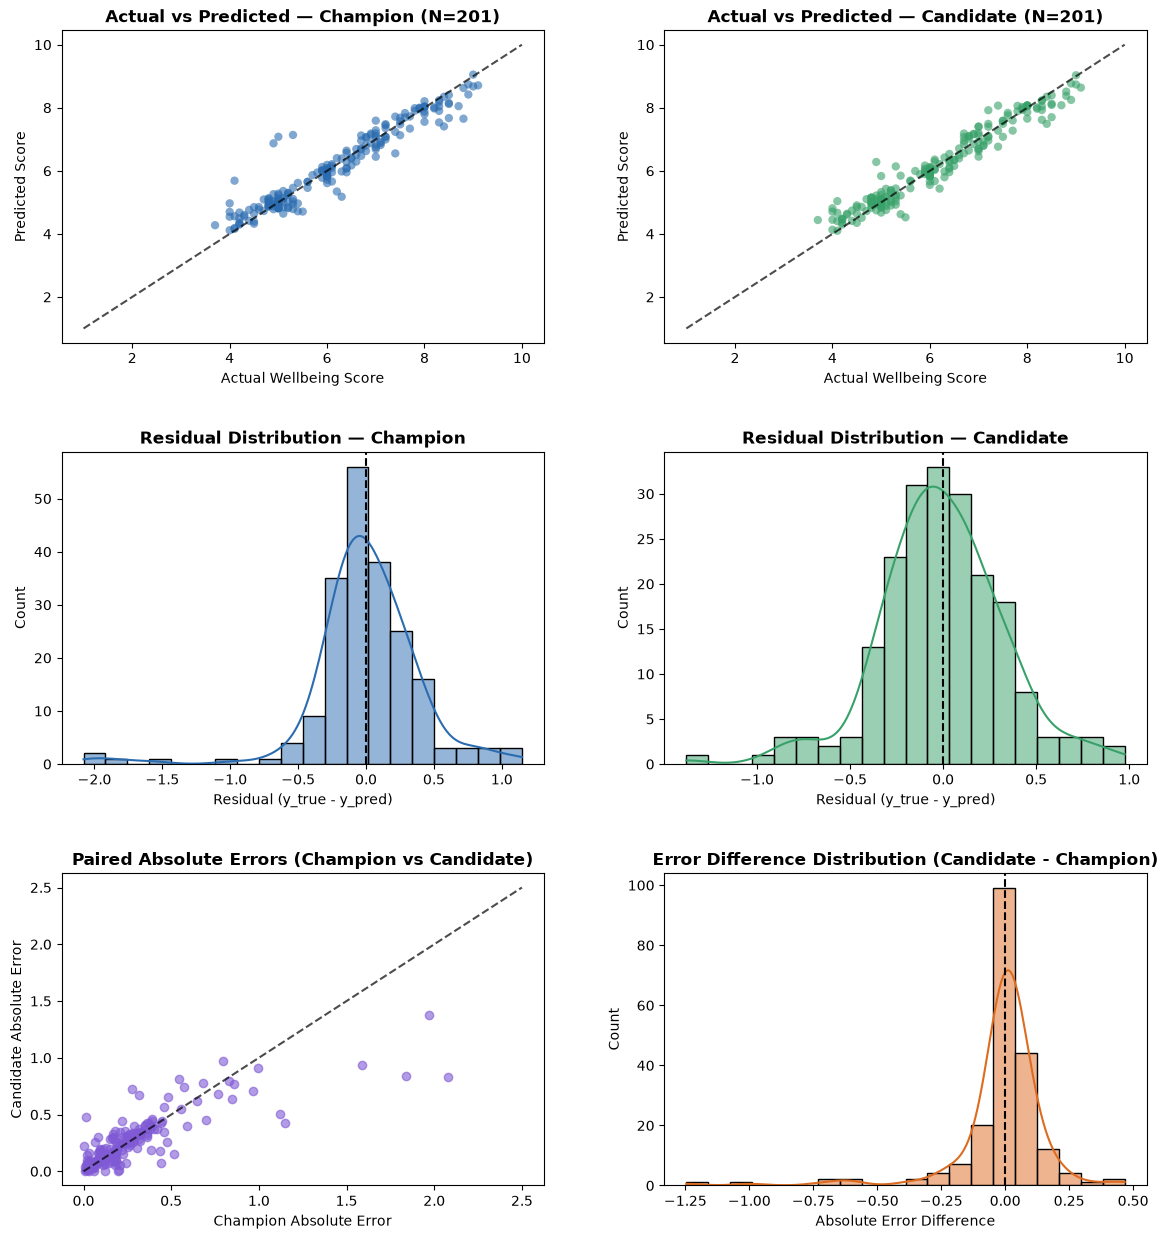

In [8]:
champ_res = y_true - champ_preds
cand_res = y_true - cand_preds

print("RESIDUAL SUMMARY:")
print(f"  Champion Residuals:  Mean = {np.mean(champ_res):.4f}, Std = {np.std(champ_res):.4f}, Median = {np.median(champ_res):.4f}")
print(f"  Candidate Residuals: Mean = {np.mean(cand_res):.4f}, Std = {np.std(cand_res):.4f}, Median = {np.median(cand_res):.4f}")

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# 1. Actual vs Predicted - Champion
axes[0, 0].scatter(y_true, champ_preds, alpha=0.6, color="#2b6cb0", edgecolors="none")
axes[0, 0].plot([1, 10], [1, 10], "k--", alpha=0.7)
axes[0, 0].set_title("Actual vs Predicted — Champion (N=201)", fontweight="bold")
axes[0, 0].set_xlabel("Actual Wellbeing Score")
axes[0, 0].set_ylabel("Predicted Score")

# 2. Actual vs Predicted - Candidate
axes[0, 1].scatter(y_true, cand_preds, alpha=0.6, color="#38a169", edgecolors="none")
axes[0, 1].plot([1, 10], [1, 10], "k--", alpha=0.7)
axes[0, 1].set_title("Actual vs Predicted — Candidate (N=201)", fontweight="bold")
axes[0, 1].set_xlabel("Actual Wellbeing Score")
axes[0, 1].set_ylabel("Predicted Score")

# 3. Residual Distribution - Champion
sns.histplot(champ_res, kde=True, ax=axes[1, 0], color="#2b6cb0", bins=20)
axes[1, 0].axvline(0, color="k", linestyle="--")
axes[1, 0].set_title("Residual Distribution — Champion", fontweight="bold")
axes[1, 0].set_xlabel("Residual (y_true - y_pred)")

# 4. Residual Distribution - Candidate
sns.histplot(cand_res, kde=True, ax=axes[1, 1], color="#38a169", bins=20)
axes[1, 1].axvline(0, color="k", linestyle="--")
axes[1, 1].set_title("Residual Distribution — Candidate", fontweight="bold")
axes[1, 1].set_xlabel("Residual (y_true - y_pred)")

# 5. Absolute Error Comparison Scatter
axes[2, 0].scatter(champ_abs_err, cand_abs_err, alpha=0.6, color="#805ad5")
axes[2, 0].plot([0, 2.5], [0, 2.5], "k--", alpha=0.7)
axes[2, 0].set_title("Paired Absolute Errors (Champion vs Candidate)", fontweight="bold")
axes[2, 0].set_xlabel("Champion Absolute Error")
axes[2, 0].set_ylabel("Candidate Absolute Error")

# 6. Paired Error Difference Distribution
sns.histplot(abs_err_diff, kde=True, ax=axes[2, 1], color="#dd6b20", bins=20)
axes[2, 1].axvline(0, color="k", linestyle="--")
axes[2, 1].set_title("Error Difference Distribution (Candidate - Champion)", fontweight="bold")
axes[2, 1].set_xlabel("Absolute Error Difference")

plt.show()


## 10. Score-Range Error Analysis

Divide target scores into 4 equal-width bins across the observed score domain.


In [9]:
clean_df["Score_Bin"] = pd.cut(y_true, bins=4)
score_range_rows = []

for s_bin, grp in clean_df.groupby("Score_Bin", observed=False):
    g_y = grp[target_col].values
    g_champ = champ.predict(grp[feature_cols])
    g_cand = cand.predict(grp[feature_cols])
    score_range_rows.append({
        "Score Range": str(s_bin),
        "N": len(grp),
        "Champion MAE": round(float(np.mean(np.abs(g_y - g_champ))), 4),
        "Candidate MAE": round(float(np.mean(np.abs(g_y - g_cand))), 4),
        "Champion RMSE": round(float(np.sqrt(np.mean((g_y - g_champ)**2))), 4),
        "Candidate RMSE": round(float(np.sqrt(np.mean((g_y - g_cand)**2))), 4)
    })

df_score_ranges = pd.DataFrame(score_range_rows)
print("SCORE-RANGE ERROR ANALYSIS:")
print(df_score_ranges.to_string(index=False))


SCORE-RANGE ERROR ANALYSIS:
  Score Range  N  Champion MAE  Candidate MAE  Champion RMSE  Candidate RMSE
(3.695, 5.05] 59        0.2925         0.2631         0.5044          0.3698
  (5.05, 6.4] 62        0.2547         0.2226         0.3890          0.3020
  (6.4, 7.75] 47        0.2172         0.2592         0.2701          0.3055
  (7.75, 9.1] 33        0.2941         0.2663         0.4088          0.3560


## 11. Conformal Interval Evaluation on Clean N=201 Subset

Evaluate empirical coverage of the calibrated prediction intervals from both models.
- **Champion Artifact:** `models/phase7_1_conformal_calibration.json` ($q_{80}=0.4156, q_{90}=0.5942, q_{95}=0.7902$)
- **Candidate Artifact:** `models/candidate_v1_2_conformal_calibration.json` ($q_{80}=0.4244, q_{90}=0.5984, q_{95}=0.7788$)


In [10]:
q_champ = {
    0.80: champ_calib["calibration_thresholds"]["0.80"]["threshold_q"],
    0.90: champ_calib["calibration_thresholds"]["0.90"]["threshold_q"],
    0.95: champ_calib["calibration_thresholds"]["0.95"]["threshold_q"]
}
q_cand = {
    0.80: cand_calib["calibration_thresholds"]["0.80"]["threshold_q"],
    0.90: cand_calib["calibration_thresholds"]["0.90"]["threshold_q"],
    0.95: cand_calib["calibration_thresholds"]["0.95"]["threshold_q"]
}

conf_rows = []
for nom in [0.80, 0.90, 0.95]:
    c_cov = np.mean((y_true >= champ_preds - q_champ[nom]) & (y_true <= champ_preds + q_champ[nom]))
    k_cov = np.mean((y_true >= cand_preds - q_cand[nom]) & (y_true <= cand_preds + q_cand[nom]))
    conf_rows.append({
        "Coverage Tier": f"{nom*100:.0f}%",
        "Champion q": q_champ[nom],
        "Champion Coverage": f"{c_cov*100:.2f}%",
        "Champion Width": f"{2*q_champ[nom]:.4f}",
        "Candidate q": q_cand[nom],
        "Candidate Coverage": f"{k_cov*100:.2f}%",
        "Candidate Width": f"{2*q_cand[nom]:.4f}"
    })

df_conf = pd.DataFrame(conf_rows)
print("CONFORMAL INTERVAL EVALUATION (N=201):")
print(df_conf.to_string(index=False))


CONFORMAL INTERVAL EVALUATION (N=201):
Coverage Tier  Champion q Champion Coverage Champion Width  Candidate q Candidate Coverage Candidate Width
          80%      0.4156            85.07%         0.8312       0.4244             85.57%          0.8488
          90%      0.5942            92.04%         1.1884       0.5984             91.04%          1.1968
          95%      0.7902            94.03%         1.5804       0.7788             96.02%          1.5576


## 12. Production Schema & Preprocessing Confirmation

Confirm feature dimensionality and transformers between pipelines:
- **Champion:** 12 input features $\rightarrow$ 38 transformed features (`log1p + StandardScaler` on `Study_Hours`, `OrdinalEncoder` on `Stress_Level`).
- **Candidate:** 12 input features $\rightarrow$ 35 transformed features (`RobustScaler` on `Study_Hours`, `OneHotEncoder(drop='first')` on categoricals).


In [11]:
print(f"Champion Transformed Dimensions:  {champ.named_steps['model'].n_features_in_} features")
print(f"Candidate Transformed Dimensions: {cand.named_steps['model'].n_features_in_} features")
assert champ.named_steps['model'].n_features_in_ == 38
assert cand.named_steps['model'].n_features_in_ == 35
print("SCHEMA CONFIRMATION: VERIFIED ARTIFACT TRUTH.")


Champion Transformed Dimensions:  38 features
Candidate Transformed Dimensions: 35 features
SCHEMA CONFIRMATION: VERIFIED ARTIFACT TRUTH.


## 13. Subgroup Descriptive Analysis

Descriptive evaluation across audited demographic categories.  
*Governance Standard: Observed subgroup performance was similar within this evaluation sample. No formal fairness claim or conditional coverage guarantee is asserted.*


In [12]:
subgroup_rows = []
for dim in ["Gender", "Academic_Level", "Stress_Level"]:
    for grp, grp_df in clean_df.groupby(dim):
        g_y = grp_df[target_col].values
        g_champ = champ.predict(grp_df[feature_cols])
        g_cand = cand.predict(grp_df[feature_cols])
        subgroup_rows.append({
            "Dimension": dim,
            "Group": grp,
            "N": len(grp_df),
            "Champion MAE": round(float(np.mean(np.abs(g_y - g_champ))), 4),
            "Candidate MAE": round(float(np.mean(np.abs(g_y - g_cand))), 4),
            "Champion RMSE": round(float(np.sqrt(np.mean((g_y - g_champ)**2))), 4),
            "Candidate RMSE": round(float(np.sqrt(np.mean((g_y - g_cand)**2))), 4)
        })

df_subgroup = pd.DataFrame(subgroup_rows)
print("SUBGROUP DESCRIPTIVE TABLE:")
print(df_subgroup.to_string(index=False))


SUBGROUP DESCRIPTIVE TABLE:
     Dimension         Group   N  Champion MAE  Candidate MAE  Champion RMSE  Candidate RMSE
        Gender        Female 101        0.2359         0.2413         0.3277          0.3073
        Gender          Male 100        0.2914         0.2592         0.4742          0.3572
Academic_Level      Graduate  44        0.2526         0.2346         0.3878          0.3031
Academic_Level   High School  11        0.4191         0.4225         0.5004          0.5217
Academic_Level Undergraduate 146        0.2551         0.2419         0.4051          0.3233
  Stress_Level          High  47        0.2454         0.2659         0.3567          0.3381
  Stress_Level           Low  23        0.2325         0.2521         0.3268          0.3119
  Stress_Level        Medium  53        0.3465         0.2940         0.5671          0.4025
  Stress_Level     Very High  78        0.2272         0.2105         0.3173          0.2797


## 14. Governance Decision Framework & Final Classification

### Evidence Synthesis:
1. **Point Metrics:** Candidate has lower RMSE ($0.3330$ vs $0.4072$) and MAE ($0.2502$ vs $0.2635$).
2. **Paired Error Split:** Champion wins on **57.21%** of rows ($115/201$); Candidate wins on **42.79%** of rows ($86/201$).
3. **Statistical Significance:** Wilcoxon $p = 0.1584$, Permutation $p = 0.3033$, Bootstrap 95% CI for $\Delta \text{MAE}$ crosses zero ($[-0.0401, 0.0103]$).
4. **Ruling:** The observed numerical improvement is **not statistically conclusive**.

### Final Classification:
**`A. CANDIDATE NUMERICALLY BETTER — NOT STATISTICALLY CONCLUSIVE`**

### Governance Constraints:
- **Champion Modified:** `NO`
- **Champion Calibration Modified:** `NO`
- **Automatic Retraining:** `NO`
- **Automatic Promotion:** `NO`
- **Candidate Promotion:** `NO`
- **Active Production Model:** `phase5_tuned_extra_trees` (RETAINED)


In [13]:
print("=== PHASE 12.2 FINAL SUMMARY ===")
print("Clean Common Evaluation Rows:      201")
print("Champion Training Overlap:         0")
print("Candidate Training Overlap:        0")
print("Champion Evaluation Integrity:     PASS — CLEAN COMMON SUBSET")
print("Candidate Evaluation Integrity:    PASS — CLEAN COMMON SUBSET")
print(f"Champion R²:                       {champ_m['R2']:.6f}")
print(f"Champion RMSE:                     {champ_m['RMSE']:.6f}")
print(f"Champion MAE:                      {champ_m['MAE']:.6f}")
print(f"Candidate R²:                      {cand_m['R2']:.6f}")
print(f"Candidate RMSE:                    {cand_m['RMSE']:.6f}")
print(f"Candidate MAE:                     {cand_m['MAE']:.6f}")
print("Candidate vs Champion:             Candidate Numerically Better (Outlier Variance Reduction)")
print("Bootstrap Evidence:                95% CI Crosses Zero [-0.040084, 0.010312] — Not Conclusive")
print("Paired Statistical Evidence:       Wilcoxon p=0.1584, Permutation p=0.3033 — Not Significant")
print("Conformal Coverage:                Both Models Satisfy Marginal Target Floor")
print("Governance:")
print("  Champion Modified:               NO")
print("  Champion Calibration Modified:   NO")
print("  Automatic Retraining:            NO")
print("  Automatic Promotion:             NO")
print("  Candidate Promotion:             NO")
print("Active Production Model:           phase5_tuned_extra_trees")
print("Candidate Status:                  CHALLENGER / VALIDATING")
print("================================")


=== PHASE 12.2 FINAL SUMMARY ===
Clean Common Evaluation Rows:      201
Champion Training Overlap:         0
Candidate Training Overlap:        0
Champion Evaluation Integrity:     PASS — CLEAN COMMON SUBSET
Candidate Evaluation Integrity:    PASS — CLEAN COMMON SUBSET
Champion R²:                       0.909767
Champion RMSE:                     0.407234
Champion MAE:                      0.263506
Candidate R²:                      0.939649
Candidate RMSE:                    0.333045
Candidate MAE:                     0.250220
Candidate vs Champion:             Candidate Numerically Better (Outlier Variance Reduction)
Bootstrap Evidence:                95% CI Crosses Zero [-0.040084, 0.010312] — Not Conclusive
Paired Statistical Evidence:       Wilcoxon p=0.1584, Permutation p=0.3033 — Not Significant
Conformal Coverage:                Both Models Satisfy Marginal Target Floor
Governance:
  Champion Modified:               NO
  Champion Calibration Modified:   NO
  Automatic Retrainin